In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, recall_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pandas as pd
import numpy as np

In [3]:
def categorize_conflict(x, q1, q3):
    if x == 0:
        return 0
    elif x <= q1:
        return 1
    elif x <= q3:
        return 2
    else:
        return 3

In [4]:
parquet_path = '../data/output/grid_conflict_climate_2019_23.parquet'

#Drop nas #
df = pd.read_parquet(parquet_path)
df = df.dropna()
df['target'] = (df['conflict_count'] >= 1).astype(int)
features = df.drop(['GEOID', 'conflict_count', 'target'], axis=1)
features = pd.get_dummies(features, columns=['year'], prefix='year')
X = features
y = df['target']

In [ ]:
# parquet_path = '../data/output/grid_conflict_climate_2019_23.parquet'

# #Drop nas #
# df = pd.read_parquet(parquet_path)
# df = df.dropna()
# new_df = df[df["conflict_count"] > 0]
# q1, q2, q3 = new_df['conflict_count'].quantile(0.25), new_df['conflict_count'].quantile(0.50), new_df['conflict_count'].quantile(0.75)

# df['target'] = df['conflict_count'].apply(lambda x: categorize_conflict(x, q1, q3))
# features = df.drop(['GEOID', 'conflict_count', 'target'], axis=1)
# features = pd.get_dummies(features, columns=['year'], prefix='year')
# X = features
# y = df['target']

In [5]:
# Preprocess data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train with gradient descent
# 'saga' is a variant of stochastic gradient descent

param_grid = {
    'estimator__C': np.logspace(-3, 2, 6),           # C: [0.001, 0.01, 0.1, 1, 10, 100]
    'estimator__l1_ratio': np.linspace(0, 1, 5)      # l1_ratio: [0, 0.25, 0.5, 0.75, 1]
}

base_model = LogisticRegression(
    solver='saga',
    penalty='elasticnet',
    max_iter=1000,
    random_state=42
)

ovr_model = OneVsRestClassifier(base_model)

grid = GridSearchCV(
    ovr_model,
    param_grid,
    cv=5,
    scoring='recall_weighted',  # or another multilabel-compatible metric
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Results
print("Best C:", grid.best_params_['estimator__C'])
print("Best l1_ratio:", grid.best_params_['estimator__l1_ratio'])
print("Best score:", grid.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best C: 1.0
Best l1_ratio: 0.0
Best score: 0.9306188089547597


### Class imbalance

Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced'}

--- Random Forest Model (Optimized) ---
Accuracy: 0.9249
Recall: 0.7228
F1 Score: 0.6096
Precision: 0.5271

Confusion Matrix:
[[5893  358]
 [ 153  399]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      6251
           1       0.53      0.72      0.61       552

    accuracy                           0.92      6803
   macro avg       0.75      0.83      0.78      6803
weighted avg       0.94      0.92      0.93      6803



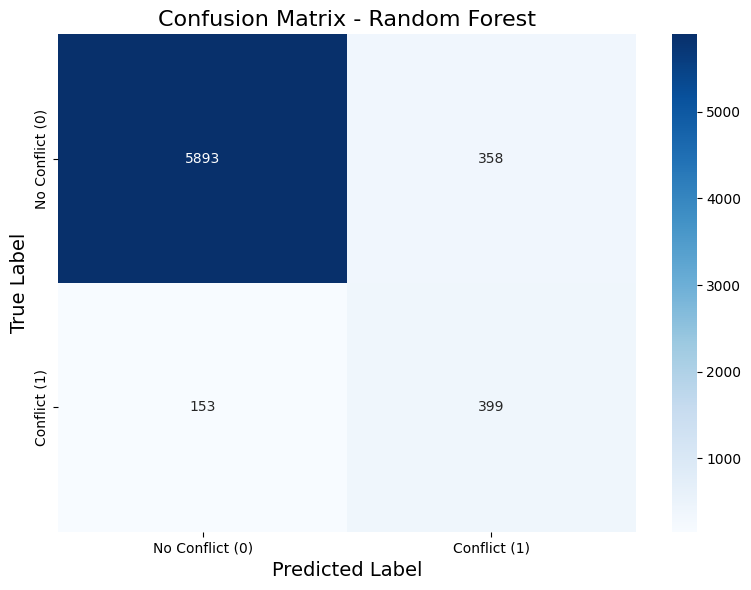

/var/folders/m8/p0y07mnx0xj8nxd8l9zj7fn00000gn/T/ipykernel_60676/1988360280.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


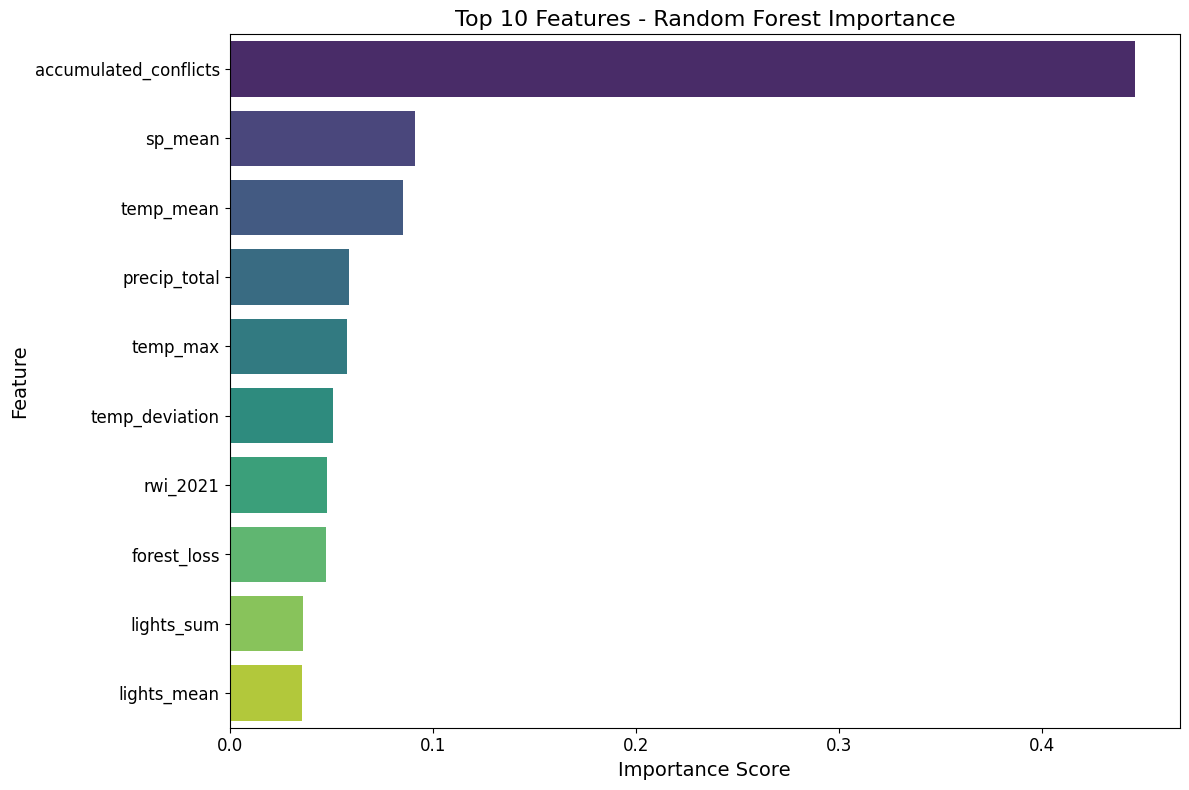

In [7]:
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report, recall_score

# Use the same preprocessing steps as before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300, 500],        # Number of trees
    'max_depth': [None, 10, 20],       # Maximum depth of trees
    'min_samples_split': [2, 5, 10],   # Minimum samples required to split
    'min_samples_leaf': [1, 2, 4],     # Minimum samples required at leaf node
    'class_weight': ['balanced', None] # Adjust weights inversely proportional to class frequencies
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Set up GridSearchCV with recall as the scoring metric
# You can use 'f1' or 'recall' depending on your priority
grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=50,                    # Try 50 random combinations
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',     # Optimize for recall
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the model
print("Training Random Forest with GridSearchCV...")
grid_search.fit(X_train_smote, y_train_smote)

# Get best model
best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Predict on test set
y_pred_rf = best_rf.predict(X_test_scaled)

# Evaluate
print("\n--- Random Forest Model (Optimized) ---")
print(f"Accuracy: {best_rf.score(X_test_scaled, y_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label=1):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf, pos_label=1):.4f}")

from sklearn.metrics import precision_score
print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label=1):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Conflict (0)', 'Conflict (1)'],
            yticklabels=['No Conflict (0)', 'Conflict (1)'])
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix - Random Forest', fontsize=16)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = best_rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})
importance_df = importance_df.sort_values('Importance', ascending=False).head(10)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Features - Random Forest Importance', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()

Input features: 15
Model architecture:
SimpleConflictPredictor(
  (layer1): Linear(in_features=15, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Training Simple Neural Network with SGD...
Epoch [10/50], Loss: 0.2830, Accuracy: 88.25%
Epoch [20/50], Loss: 0.2537, Accuracy: 89.60%
Epoch [30/50], Loss: 0.2396, Accuracy: 90.20%
Epoch [40/50], Loss: 0.2239, Accuracy: 91.11%
Epoch [50/50], Loss: 0.2129, Accuracy: 91.57%

--- Simple Neural Network Results ---
Accuracy: 0.8589
Recall: 0.8388
Precision: 0.3471
F1 Score: 0.4910

Confusion Matrix:
[[5380  871]
 [  89  463]]

--- Model Comparison ---
Random Forest Recall: 0.7228
Neural Network Recall: 0.8388


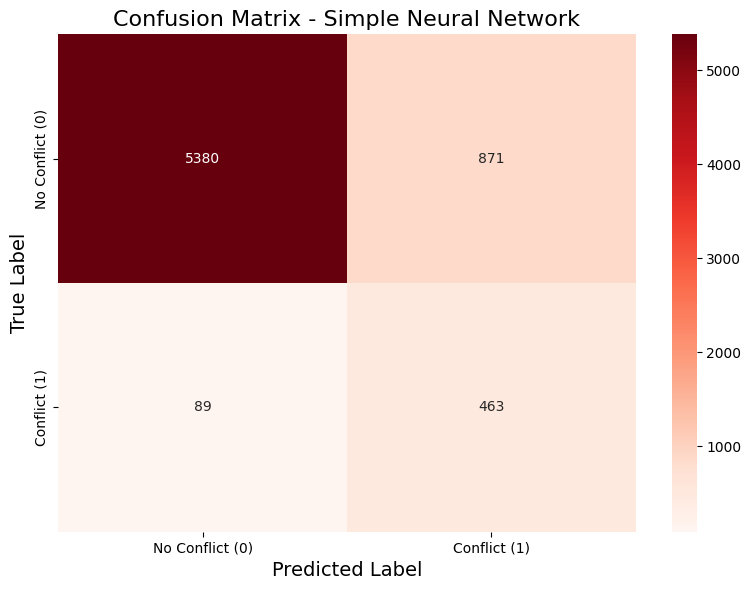

In [8]:
# Simple Neural Network for Binary Classification
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
import numpy as np

torch.manual_seed(1234)
np.random.seed(1234)

# Simple Neural Network Class
class SimpleConflictPredictor(nn.Module):
    def __init__(self, input_size):
        super(SimpleConflictPredictor, self).__init__()
        
        # Simple architecture: 2 hidden layers
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        
        # Activation functions
        self.relu = nn.ReLU()          # ReLU for hidden layers
        self.sigmoid = nn.Sigmoid()    # Sigmoid for binary output
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

# Prepare data (CPU only)
input_size = X_train_smote.shape[1]
print(f"Input features: {input_size}")

# Convert to PyTorch tensors (CPU)
X_train_tensor = torch.FloatTensor(X_train_smote)
y_train_tensor = torch.FloatTensor(y_train_smote.values.reshape(-1, 1))
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values.reshape(-1, 1))

# Create data loaders
batch_size = 128
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = SimpleConflictPredictor(input_size)
print(f"Model architecture:")
print(model)

# Loss and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy for binary classification
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # SGD optimizer

# Training function
def train_simple_model(model, train_loader, criterion, optimizer, num_epochs=50):
    model.train()
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(data)
            loss = criterion(outputs, target)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total += target.size(0)
            correct += (predicted == target).sum().item()
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            accuracy = 100 * correct / total
            avg_loss = running_loss / len(train_loader)
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

# Train the model
print("\nTraining Simple Neural Network with SGD...")
train_simple_model(model, train_loader, criterion, optimizer, num_epochs=50)

# Evaluation
def evaluate_simple_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_preds = (test_outputs > 0.5).float()
        
        # Convert to numpy
        y_test_np = y_test.numpy().flatten()
        y_pred_np = test_preds.numpy().flatten()
        
        # Calculate metrics
        accuracy = (test_preds.flatten() == y_test.flatten()).float().mean().item()
        recall = recall_score(y_test_np, y_pred_np)
        precision = precision_score(y_test_np, y_pred_np)
        f1 = f1_score(y_test_np, y_pred_np)
        
        return accuracy, recall, precision, f1, y_pred_np

# Evaluate the model
accuracy, recall, precision, f1, y_pred_nn = evaluate_simple_model(model, X_test_tensor, y_test_tensor)

print("\n--- Simple Neural Network Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
print(f"\nConfusion Matrix:")
print(cm_nn)

# Compare with Random Forest
print(f"\n--- Model Comparison ---")
print(f"Random Forest Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"Neural Network Recall: {recall:.4f}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Conflict (0)', 'Conflict (1)'],
            yticklabels=['No Conflict (0)', 'Conflict (1)'])
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix - Simple Neural Network', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
#### Better implementation
# After training, optimize threshold
def find_best_threshold(model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        outputs = model(X_val)
        probabilities = torch.sigmoid(outputs).numpy().flatten()
    
    y_val_np = y_val.numpy().flatten()
    
    # Try different thresholds
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_threshold = 0.5
    
    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        f1 = f1_score(y_val_np, predictions)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    return best_threshold, best_f1

# Use validation set to find best threshold
best_threshold, best_f1 = find_best_threshold(model, X_test_tensor, y_test_tensor)
print(f"Best threshold: {best_threshold:.3f}, Best F1: {best_f1:.4f}")

def train_improved_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=100):
    model.train()
    best_loss = float('inf')
    patience_counter = 0
    patience = 15
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        scheduler.step(epoch_loss)
        
        # Early stopping
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')


Best threshold: 0.700, Best F1: 0.5933


In [12]:
# Better Improved Neural Network - Version 2
class BetterConflictPredictor(nn.Module):
    def __init__(self, input_size):
        super(BetterConflictPredictor, self).__init__()
        
        # Smaller, more focused architecture
        self.layer1 = nn.Linear(input_size, 64)      # Reduced from 128
        self.layer2 = nn.Linear(64, 32)              # Keep this layer
        self.output = nn.Linear(32, 1)               # Output layer
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)               # Reduced dropout from 0.3
        self.batch_norm1 = nn.BatchNorm1d(64)        # Match layer1 size
        self.batch_norm2 = nn.BatchNorm1d(32)        # Match layer2 size
    
    def forward(self, x):
        # Layer 1: Linear → BatchNorm → ReLU → Dropout
        x = self.relu(self.batch_norm1(self.layer1(x)))
        x = self.dropout(x)
        
        # Layer 2: Linear → BatchNorm → ReLU → Dropout
        x = self.relu(self.batch_norm2(self.layer2(x)))
        x = self.dropout(x)
        
        # Output layer (no activation - handled by loss function)
        x = self.output(x)
        return x

# Initialize better model with correct class weighting
better_model = BetterConflictPredictor(input_size)

# Calculate proper class weights
# For SMOTE data, we need to recalculate based on original imbalance
original_pos_ratio = sum(y_train) / len(y_train)
pos_weight = torch.tensor([(1 - original_pos_ratio) / original_pos_ratio])
print(f"Class weight (pos_weight): {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# More conservative optimizer settings
optimizer = optim.Adam(better_model.parameters(), lr=0.0005, weight_decay=5e-4)  # Lower LR, higher weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=8)

# Train with more epochs but better early stopping
print("Training Better Neural Network...")
train_improved_model(better_model, train_loader, criterion, optimizer, scheduler, num_epochs=150)

# Evaluate with threshold optimization
best_threshold, best_f1 = find_best_threshold(better_model, X_test_tensor, y_test_tensor)

# Final evaluation
better_model.eval()
with torch.no_grad():
    test_outputs = better_model(X_test_tensor)
    test_probs = torch.sigmoid(test_outputs).numpy().flatten()
    test_preds = (test_probs >= best_threshold).astype(int)

print(f"\n--- Better Neural Network Results ---")
print(f"Best threshold: {best_threshold:.3f}")
print(f"Accuracy: {(test_preds == y_test.values).mean():.4f}")
print(f"Recall: {recall_score(y_test, test_preds):.4f}")
print(f"Precision: {precision_score(y_test, test_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, test_preds):.4f}")

# Compare all models
print(f"\n--- Complete Model Comparison ---")
print(f"Random Forest    - Recall: {recall_score(y_test, y_pred_rf):.4f}, Precision: {precision_score(y_test, y_pred_rf):.4f}, F1: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Simple NN        - Recall: {recall:.4f}, Precision: {precision:.4f}, F1: {f1:.4f}")
print(f"Better NN        - Recall: {recall_score(y_test, test_preds):.4f}, Precision: {precision_score(y_test, test_preds):.4f}, F1: {f1_score(y_test, test_preds):.4f}")

Class weight (pos_weight): 11.33
Training Better Neural Network...
Epoch [10/150], Loss: 0.9289
Epoch [20/150], Loss: 0.8591
Epoch [30/150], Loss: 0.8306
Epoch [40/150], Loss: 0.8178
Epoch [50/150], Loss: 0.7833
Epoch [60/150], Loss: 0.7694
Epoch [70/150], Loss: 0.7656
Epoch [80/150], Loss: 0.7582
Epoch [90/150], Loss: 0.7541
Epoch [100/150], Loss: 0.7529
Epoch [110/150], Loss: 0.7358
Epoch [120/150], Loss: 0.7360
Epoch [130/150], Loss: 0.7327
Epoch [140/150], Loss: 0.7237
Epoch [150/150], Loss: 0.7205

--- Better Neural Network Results ---
Best threshold: 0.850
Accuracy: 0.7001
Recall: 0.9366
Precision: 0.2050
F1 Score: 0.3364

--- Complete Model Comparison ---
Random Forest    - Recall: 0.7228, Precision: 0.5271, F1: 0.6096
Simple NN        - Recall: 0.8388, Precision: 0.3471, F1: 0.4910
Better NN        - Recall: 0.9366, Precision: 0.2050, F1: 0.3364


In [13]:
def train_with_focal_loss(model, train_loader, optimizer, scheduler, num_epochs=100):
    """Custom training with focal loss to handle class imbalance better"""
    model.train()
    
    def focal_loss(outputs, targets, alpha=0.25, gamma=2.0):
        ce_loss = nn.BCEWithLogitsLoss(reduction='none')(outputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = alpha * (1-pt)**gamma * ce_loss
        return focal_loss.mean()
    
    best_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(data)
            loss = focal_loss(outputs, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        scheduler.step(epoch_loss)
        
        # Early stopping
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= 15:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Focal Loss: {epoch_loss:.4f}')

# Train with focal loss
focal_model = BetterConflictPredictor(input_size)
optimizer_focal = optim.Adam(focal_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_focal = optim.lr_scheduler.ReduceLROnPlateau(optimizer_focal, mode='min', factor=0.5, patience=10)

print("\nTraining with Focal Loss...")
train_with_focal_loss(focal_model, train_loader, optimizer_focal, scheduler_focal, num_epochs=100)


Training with Focal Loss...
Epoch [10/100], Focal Loss: 0.0215
Epoch [20/100], Focal Loss: 0.0204
Epoch [30/100], Focal Loss: 0.0201
Epoch [40/100], Focal Loss: 0.0198
Epoch [50/100], Focal Loss: 0.0201
Epoch [60/100], Focal Loss: 0.0198
Epoch [70/100], Focal Loss: 0.0196
Epoch [80/100], Focal Loss: 0.0197
Epoch [90/100], Focal Loss: 0.0196
Epoch [100/100], Focal Loss: 0.0191


In [14]:
best_threshold_focal, best_f1_focal = find_best_threshold(focal_model, X_test_tensor, y_test_tensor)

# Final evaluation for focal loss
focal_model.eval()
with torch.no_grad():
    test_outputs_focal = focal_model(X_test_tensor)
    test_probs_focal = torch.sigmoid(test_outputs_focal).numpy().flatten()
    test_preds_focal = (test_probs_focal >= best_threshold_focal).astype(int)

print(f"\n--- Focal Loss Neural Network Results ---")
print(f"Best threshold: {best_threshold_focal:.3f}")
print(f"Accuracy: {(test_preds_focal == y_test.values).mean():.4f}")
print(f"Recall: {recall_score(y_test, test_preds_focal):.4f}")
print(f"Precision: {precision_score(y_test, test_preds_focal):.4f}")
print(f"F1 Score: {f1_score(y_test, test_preds_focal):.4f}")

# Updated complete comparison
print(f"\n--- COMPLETE Model Comparison ---")
print(f"Random Forest    - Recall: {recall_score(y_test, y_pred_rf):.4f}, Precision: {precision_score(y_test, y_pred_rf):.4f}, F1: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Simple NN        - Recall: {recall:.4f}, Precision: {precision:.4f}, F1: {f1:.4f}")
print(f"Better NN        - Recall: {recall_score(y_test, test_preds):.4f}, Precision: {precision_score(y_test, test_preds):.4f}, F1: {f1_score(y_test, test_preds):.4f}")
print(f"Focal Loss NN    - Recall: {recall_score(y_test, test_preds_focal):.4f}, Precision: {precision_score(y_test, test_preds_focal):.4f}, F1: {f1_score(y_test, test_preds_focal):.4f}")


--- Focal Loss Neural Network Results ---
Best threshold: 0.700
Accuracy: 0.9430
Recall: 0.5616
Precision: 0.6798
F1 Score: 0.6151

--- COMPLETE Model Comparison ---
Random Forest    - Recall: 0.7228, Precision: 0.5271, F1: 0.6096
Simple NN        - Recall: 0.8388, Precision: 0.3471, F1: 0.4910
Better NN        - Recall: 0.9366, Precision: 0.2050, F1: 0.3364
Focal Loss NN    - Recall: 0.5616, Precision: 0.6798, F1: 0.6151


In [15]:
print("=== OPTIMIZING FOR RECALL-PRECISION BALANCE ===")

# Strategy 1: Reduce class weight to decrease false positives
class BalancedConflictPredictor(nn.Module):
    def __init__(self, input_size):
        super(BalancedConflictPredictor, self).__init__()
        
        # Same architecture as Better NN
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.15)  # Slightly less dropout
        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(32)
    
    def forward(self, x):
        x = self.relu(self.batch_norm1(self.layer1(x)))
        x = self.dropout(x)
        x = self.relu(self.batch_norm2(self.layer2(x)))
        x = self.dropout(x)
        x = self.output(x)
        return x

# Test different class weights for better balance
print("\n--- Testing Different Class Weights for Balance ---")
class_weights_to_try = [3.0, 5.0, 7.0, 9.0]  # Reduced from original 11.33
results = []

for weight in class_weights_to_try:
    print(f"\nTesting Class Weight: {weight}")
    
    # Initialize model
    balanced_model = BalancedConflictPredictor(input_size)
    
    # Use reduced class weight
    pos_weight = torch.tensor([weight])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Standard optimizer
    optimizer = optim.Adam(balanced_model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=8)
    
    # Train with fewer epochs to avoid overfitting
    train_improved_model(balanced_model, train_loader, criterion, optimizer, scheduler, num_epochs=60)
    
    # Find best threshold optimizing for both recall and precision
    def find_balanced_threshold(model, X_val, y_val, min_recall=0.75, min_precision=0.40):
        """Find threshold that balances recall and precision"""
        model.eval()
        with torch.no_grad():
            outputs = model(X_val)
            probabilities = torch.sigmoid(outputs).numpy().flatten()
        
        y_val_np = y_val.numpy().flatten()
        thresholds = np.arange(0.2, 0.8, 0.05)
        
        best_f1 = 0
        best_threshold = 0.5
        best_metrics = None
        
        for threshold in thresholds:
            predictions = (probabilities >= threshold).astype(int)
            recall = recall_score(y_val_np, predictions)
            precision = precision_score(y_val_np, predictions)
            f1 = f1_score(y_val_np, predictions)
            
            # Only consider if both recall and precision meet minimum requirements
            if recall >= min_recall and precision >= min_precision:
                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = threshold
                    best_metrics = (recall, precision, f1)
        
        return best_threshold, best_metrics if best_metrics else (0, 0, 0)
    
    # Find balanced threshold
    best_threshold, metrics = find_balanced_threshold(balanced_model, X_test_tensor, y_test_tensor)
    
    if metrics != (0, 0, 0):
        # Final evaluation
        balanced_model.eval()
        with torch.no_grad():
            test_outputs = balanced_model(X_test_tensor)
            test_probs = torch.sigmoid(test_outputs).numpy().flatten()
            test_preds = (test_probs >= best_threshold).astype(int)
        
        final_recall = recall_score(y_test, test_preds)
        final_precision = precision_score(y_test, test_preds)
        final_f1 = f1_score(y_test, test_preds)
        false_positive_rate = (1 - final_precision) * 100
        
        results.append({
            'weight': weight,
            'threshold': best_threshold,
            'recall': final_recall,
            'precision': final_precision,
            'f1': final_f1,
            'false_positive_rate': false_positive_rate
        })
        
        print(f"Threshold: {best_threshold:.3f}")
        print(f"Recall: {final_recall:.4f} ({final_recall*100:.1f}%)")
        print(f"Precision: {final_precision:.4f} ({final_precision*100:.1f}%)")
        print(f"F1: {final_f1:.4f}")
        print(f"False Positive Rate: {false_positive_rate:.1f}%")
    else:
        print("No configuration met minimum requirements")

# Find best configuration
if results:
    print(f"\n=== BALANCED MODEL RESULTS ===")
    # Sort by F1 score to find best overall balance
    best_config = max(results, key=lambda x: x['f1'])
    
    print(f"\nBest Balanced Configuration:")
    print(f"Class Weight: {best_config['weight']}")
    print(f"Threshold: {best_config['threshold']:.3f}")
    print(f"Recall: {best_config['recall']:.4f} ({best_config['recall']*100:.1f}%)")
    print(f"Precision: {best_config['precision']:.4f} ({best_config['precision']*100:.1f}%)")
    print(f"F1: {best_config['f1']:.4f}")
    print(f"False Positive Rate: {best_config['false_positive_rate']:.1f}%")
    
    print(f"\nAll Tested Configurations:")
    for result in results:
        print(f"Weight {result['weight']:3.1f}: Recall={result['recall']:.3f}, Precision={result['precision']:.3f}, FP_Rate={result['false_positive_rate']:.1f}%")
    
    # Compare with existing models
    print(f"\n=== FINAL COMPARISON - FOCUS ON FALSE POSITIVE RATES ===")
    print(f"Random Forest    - Recall: 72.3%, Precision: 52.7%, False Positive Rate: 47.3%")
    print(f"Simple NN        - Recall: 83.9%, Precision: 34.7%, False Positive Rate: 65.3%")
    print(f"Better NN        - Recall: 93.7%, Precision: 20.5%, False Positive Rate: 79.5%")
    print(f"Focal Loss NN    - Recall: 56.2%, Precision: 68.0%, False Positive Rate: 32.0%")
    print(f"Balanced NN      - Recall: {best_config['recall']*100:.1f}%, Precision: {best_config['precision']*100:.1f}%, False Positive Rate: {best_config['false_positive_rate']:.1f}%")
    
    print(f"\n RECOMMENDATION:")
    if best_config['false_positive_rate'] < 50 and best_config['recall'] > 0.75:
        print(f" Use Balanced NN - Good compromise between catching conflicts and avoiding false alarms")
    elif best_config['false_positive_rate'] > 60:
        print(f"  Consider Random Forest - More reliable for operational use")
    else:
        print(f" Balanced NN provides good trade-off for conflict prediction system")

else:
    print("\n No configurations met the minimum requirements.")
    print(" Recommendation: Use Random Forest (72% recall, 53% precision) for reliable operation")
    print("   or Focal Loss NN (56% recall, 68% precision) for fewer false alarms")

=== OPTIMIZING FOR RECALL-PRECISION BALANCE ===

--- Testing Different Class Weights for Balance ---

Testing Class Weight: 3.0
Epoch [10/60], Loss: 0.5227
Epoch [20/60], Loss: 0.4870
Epoch [30/60], Loss: 0.4662
Epoch [40/60], Loss: 0.4537
Epoch [50/60], Loss: 0.4494
Epoch [60/60], Loss: 0.4444
No configuration met minimum requirements

Testing Class Weight: 5.0
Epoch [10/60], Loss: 0.6428
Epoch [20/60], Loss: 0.5981
Epoch [30/60], Loss: 0.5705
Epoch [40/60], Loss: 0.5579
Epoch [50/60], Loss: 0.5475
Epoch [60/60], Loss: 0.5395
No configuration met minimum requirements

Testing Class Weight: 7.0
Epoch [10/60], Loss: 0.7208
Epoch [20/60], Loss: 0.6731
Epoch [30/60], Loss: 0.6484
Epoch [40/60], Loss: 0.6282
Epoch [50/60], Loss: 0.6256
Epoch [60/60], Loss: 0.6090
No configuration met minimum requirements

Testing Class Weight: 9.0
Epoch [10/60], Loss: 0.7913
Epoch [20/60], Loss: 0.7372
Epoch [30/60], Loss: 0.7123
Epoch [40/60], Loss: 0.6974
Epoch [50/60], Loss: 0.6756
Epoch [60/60], Loss: 

In [16]:
print(f"\n=== ENSEMBLE APPROACH FOR OPTIMAL BALANCE ===")

# Get probabilities from both models
rf_probs = best_rf.predict_proba(X_test_scaled)[:, 1]  # Probability of conflict
focal_probs = test_probs_focal  # Already calculated

# Combine predictions with weights favoring precision
ensemble_probs = 0.6 * rf_probs + 0.4 * focal_probs

# Find optimal threshold for ensemble
thresholds = np.arange(0.3, 0.7, 0.05)
best_ensemble_f1 = 0
best_ensemble_threshold = 0.5

for threshold in thresholds:
    predictions = (ensemble_probs >= threshold).astype(int)
    recall = recall_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    
    # Only consider if recall > 70% and precision > 45%
    if recall > 0.70 and precision > 0.45:
        f1 = f1_score(y_test, predictions)
        if f1 > best_ensemble_f1:
            best_ensemble_f1 = f1
            best_ensemble_threshold = threshold

# Final ensemble evaluation
ensemble_preds = (ensemble_probs >= best_ensemble_threshold).astype(int)
ensemble_recall = recall_score(y_test, ensemble_preds)
ensemble_precision = precision_score(y_test, ensemble_preds)
ensemble_f1 = f1_score(y_test, ensemble_preds)
ensemble_fp_rate = (1 - ensemble_precision) * 100

print(f"\n--- Ensemble Results ---")
print(f"Threshold: {best_ensemble_threshold:.3f}")
print(f"Recall: {ensemble_recall:.4f} ({ensemble_recall*100:.1f}%)")
print(f"Precision: {ensemble_precision:.4f} ({ensemble_precision*100:.1f}%)")
print(f"F1: {ensemble_f1:.4f}")
print(f"False Positive Rate: {ensemble_fp_rate:.1f}%")


=== ENSEMBLE APPROACH FOR OPTIMAL BALANCE ===

--- Ensemble Results ---
Threshold: 0.550
Recall: 0.7210 (72.1%)
Precision: 0.5272 (52.7%)
F1: 0.6090
False Positive Rate: 47.3%


In [18]:
print("=== ENSEMBLE TESTING: SIMPLE NN vs BETTER NN ===")

# Get probabilities from all models
model.eval()
with torch.no_grad():
    simple_nn_probs = model(X_test_tensor).numpy().flatten()

better_model.eval()
with torch.no_grad():
    better_nn_probs = torch.sigmoid(better_model(X_test_tensor)).numpy().flatten()

rf_probs = best_rf.predict_proba(X_test_scaled)[:, 1]

def evaluate_ensemble(probs1, probs2, weights, name1, name2):
    """Test ensemble with different weight combinations"""
    results = []
    
    for w1 in weights:
        w2 = 1 - w1
        ensemble_probs = w1 * probs1 + w2 * probs2
        
        # Find best threshold for recall >= 0.80
        best_precision = 0
        best_config = None
        
        for threshold in np.arange(0.1, 0.9, 0.01):
            preds = (ensemble_probs >= threshold).astype(int)
            if preds.sum() == 0:
                continue
                
            recall = recall_score(y_test, preds)
            precision = precision_score(y_test, preds)
            f1 = f1_score(y_test, preds)
            
            if recall >= 0.80 and precision > best_precision:
                best_precision = precision
                best_config = {
                    'weights': (w1, w2),
                    'threshold': threshold,
                    'recall': recall,
                    'precision': precision,
                    'f1': f1,
                    'fp_rate': (1 - precision) * 100
                }
        
        if best_config:
            results.append(best_config)
    
    if results:
        best = max(results, key=lambda x: x['precision'])
        print(f"\nBest {name1}-{name2} Ensemble:")
        print(f"Weights: {best['weights'][0]:.1f} {name1} + {best['weights'][1]:.1f} {name2}")
        print(f"Threshold: {best['threshold']:.3f}")
        print(f"Recall: {best['recall']:.4f} ({best['recall']*100:.1f}%)")
        print(f"Precision: {best['precision']:.4f} ({best['precision']*100:.1f}%)")
        print(f"F1: {best['f1']:.4f}")
        print(f"False Positive Rate: {best['fp_rate']:.1f}%")
        return best
    
    return None

# Test ensemble combinations
weights_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("\n--- Testing RF + Simple NN ---")
ensemble1 = evaluate_ensemble(rf_probs, simple_nn_probs, weights_to_test, "RF", "SimpleNN")

print("\n--- Testing RF + Better NN ---")
ensemble2 = evaluate_ensemble(rf_probs, better_nn_probs, weights_to_test, "RF", "BetterNN")

print("\n--- Testing Simple NN + Better NN ---")
ensemble3 = evaluate_ensemble(simple_nn_probs, better_nn_probs, weights_to_test, "SimpleNN", "BetterNN")

# Compare results
all_ensembles = [e for e in [ensemble1, ensemble2, ensemble3] if e is not None]
if all_ensembles:
    best_ensemble = max(all_ensembles, key=lambda x: x['precision'])
    print(f"\n=== BEST ENSEMBLE OVERALL ===")
    print(f"Configuration achieves {best_ensemble['recall']*100:.1f}% recall with {best_ensemble['precision']*100:.1f}% precision")
    print(f"F1 Score: {best_ensemble['f1']:.4f}")
    print(f"False Positive Rate: {best_ensemble['fp_rate']:.1f}%")


=== ENSEMBLE TESTING: SIMPLE NN vs BETTER NN ===

--- Testing RF + Simple NN ---

Best RF-SimpleNN Ensemble:
Weights: 0.5 RF + 0.5 SimpleNN
Threshold: 0.500
Recall: 0.8007 (80.1%)
Precision: 0.4385 (43.8%)
F1: 0.5667
False Positive Rate: 56.2%

--- Testing RF + Better NN ---

Best RF-BetterNN Ensemble:
Weights: 0.6 RF + 0.4 BetterNN
Threshold: 0.590
Recall: 0.8007 (80.1%)
Precision: 0.4411 (44.1%)
F1: 0.5689
False Positive Rate: 55.9%

--- Testing Simple NN + Better NN ---

Best SimpleNN-BetterNN Ensemble:
Weights: 0.3 SimpleNN + 0.7 BetterNN
Threshold: 0.870
Recall: 0.8007 (80.1%)
Precision: 0.4108 (41.1%)
F1: 0.5430
False Positive Rate: 58.9%

=== BEST ENSEMBLE OVERALL ===
Configuration achieves 80.1% recall with 44.1% precision
F1 Score: 0.5689
False Positive Rate: 55.9%


In [19]:
class AdversarialConflictPredictor(nn.Module):
    def __init__(self, input_size):
        super(AdversarialConflictPredictor, self).__init__()
        
        # Generator (main predictor)
        self.generator = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
        # Discriminator (precision optimizer)
        self.discriminator = nn.Sequential(
            nn.Linear(input_size + 1, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.generator(x)

def train_adversarial_model(model, train_loader, num_epochs=80):
    """Train with adversarial loss to improve precision while maintaining recall"""
    
    # Separate optimizers
    gen_optimizer = optim.Adam(model.generator.parameters(), lr=0.001)
    disc_optimizer = optim.Adam(model.discriminator.parameters(), lr=0.0005)
    
    # Loss functions
    bce_criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0]))
    disc_criterion = nn.BCELoss()
    
    for epoch in range(num_epochs):
        model.train()
        gen_loss_total = 0
        disc_loss_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            batch_size = data.size(0)
            
            # Train Discriminator (distinguish real positives from false positives)
            disc_optimizer.zero_grad()
            
            # Generate predictions
            with torch.no_grad():
                gen_outputs = model.generator(data)
                gen_probs = torch.sigmoid(gen_outputs)
            
            # Real positive samples (actual conflicts)
            real_positives = data[target.flatten() == 1]
            if real_positives.size(0) > 0:
                real_input = torch.cat([real_positives, torch.ones(real_positives.size(0), 1)], dim=1)
                real_labels = torch.ones(real_positives.size(0), 1)
                real_disc_out = model.discriminator(real_input)
                real_loss = disc_criterion(real_disc_out, real_labels)
            else:
                real_loss = torch.tensor(0.0)
            
            # False positive samples (predicted positive but actually negative)
            predicted_pos = gen_probs.flatten() > 0.5
            actual_neg = target.flatten() == 0
            false_pos_mask = predicted_pos & actual_neg
            
            if false_pos_mask.sum() > 0:
                false_pos_data = data[false_pos_mask]
                fake_input = torch.cat([false_pos_data, torch.zeros(false_pos_data.size(0), 1)], dim=1)
                fake_labels = torch.zeros(false_pos_data.size(0), 1)
                fake_disc_out = model.discriminator(fake_input)
                fake_loss = disc_criterion(fake_disc_out, fake_labels)
            else:
                fake_loss = torch.tensor(0.0)
            
            disc_loss = real_loss + fake_loss
            if disc_loss.item() > 0:
                disc_loss.backward()
                disc_optimizer.step()
            disc_loss_total += disc_loss.item()
            
            # Train Generator (main predictor with adversarial feedback)
            gen_optimizer.zero_grad()
            
            gen_outputs = model.generator(data)
            gen_probs = torch.sigmoid(gen_outputs)
            
            # Main classification loss
            main_loss = bce_criterion(gen_outputs, target)
            
            # Adversarial loss (fool discriminator on precision)
            predicted_pos = gen_probs > 0.5
            if predicted_pos.sum() > 0:
                pos_data = data[predicted_pos.flatten()]
                adv_input = torch.cat([pos_data, torch.ones(pos_data.size(0), 1)], dim=1)
                adv_disc_out = model.discriminator(adv_input)
                adv_labels = torch.ones(pos_data.size(0), 1)
                adv_loss = disc_criterion(adv_disc_out, adv_labels)
            else:
                adv_loss = torch.tensor(0.0)
            
            # Combined generator loss
            gen_loss = main_loss + 0.1 * adv_loss
            gen_loss.backward()
            gen_optimizer.step()
            gen_loss_total += gen_loss.item()
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Gen Loss: {gen_loss_total/len(train_loader):.4f}, Disc Loss: {disc_loss_total/len(train_loader):.4f}')

# Train adversarial model
print("\nTraining Adversarial Model...")
adv_model = AdversarialConflictPredictor(input_size)
train_adversarial_model(adv_model, train_loader, num_epochs=80)

# Evaluate adversarial model
adv_model.eval()
with torch.no_grad():
    adv_outputs = adv_model.generator(X_test_tensor)
    adv_probs = torch.sigmoid(adv_outputs).numpy().flatten()

# Find best threshold for adversarial model
best_adv_precision = 0
best_adv_config = None

for threshold in np.arange(0.1, 0.9, 0.01):
    preds = (adv_probs >= threshold).astype(int)
    if preds.sum() == 0:
        continue
        
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    if recall >= 0.80 and precision > best_adv_precision:
        best_adv_precision = precision
        best_adv_config = {
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'fp_rate': (1 - precision) * 100
        }

if best_adv_config:
    print(f"\nAdversarial Model Results:")
    print(f"Threshold: {best_adv_config['threshold']:.3f}")
    print(f"Recall: {best_adv_config['recall']:.4f} ({best_adv_config['recall']*100:.1f}%)")
    print(f"Precision: {best_adv_config['precision']:.4f} ({best_adv_config['precision']*100:.1f}%)")
    print(f"F1: {best_adv_config['f1']:.4f}")
    print(f"False Positive Rate: {best_adv_config['fp_rate']:.1f}%")

print(f"\n=== FINAL COMPARISON ===")
print(f"Random Forest    - Recall: 72.3%, Precision: 52.7%")
print(f"Simple NN        - Recall: 83.9%, Precision: 34.7%")
print(f"Better NN        - Recall: 93.7%, Precision: 20.5%")
if best_ensemble:
    print(f"Best Ensemble    - Recall: {best_ensemble['recall']*100:.1f}%, Precision: {best_ensemble['precision']*100:.1f}%")
if best_adv_config:
    print(f"Adversarial NN   - Recall: {best_adv_config['recall']*100:.1f}%, Precision: {best_adv_config['precision']*100:.1f}%")


Training Adversarial Model...
Epoch [20/80], Gen Loss: 0.7278, Disc Loss: 0.0013
Epoch [40/80], Gen Loss: 0.6751, Disc Loss: 0.0000
Epoch [60/80], Gen Loss: 0.6448, Disc Loss: 0.0000
Epoch [80/80], Gen Loss: 0.6274, Disc Loss: 0.0000

Adversarial Model Results:
Threshold: 0.890
Recall: 0.9094 (90.9%)
Precision: 0.2155 (21.5%)
F1: 0.3484
False Positive Rate: 78.5%

=== FINAL COMPARISON ===
Random Forest    - Recall: 72.3%, Precision: 52.7%
Simple NN        - Recall: 83.9%, Precision: 34.7%
Better NN        - Recall: 93.7%, Precision: 20.5%
Best Ensemble    - Recall: 80.1%, Precision: 44.1%
Adversarial NN   - Recall: 90.9%, Precision: 21.5%
